<a href="https://colab.research.google.com/github/Aliabdrabo/CI_SOM---PCA/blob/main/CI_SOM_%26_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install minisom

  Preparing metadata (setup.py) ... done
  Created wheel for minisom: filename=MiniSom-2.3.5-py3-none-any.whl size=12031 sha256=6f427a4d1372a1bd82298f67fb9959164bff359a7cedd9b9b3cb5f4d6ca3983d
  Stored in directory: /root/.cache/pip/wheels/19/db/95/5e53bc2b88a328217fdf9f2886cafbe86b0df274f4b601f572
Successfully built minisom


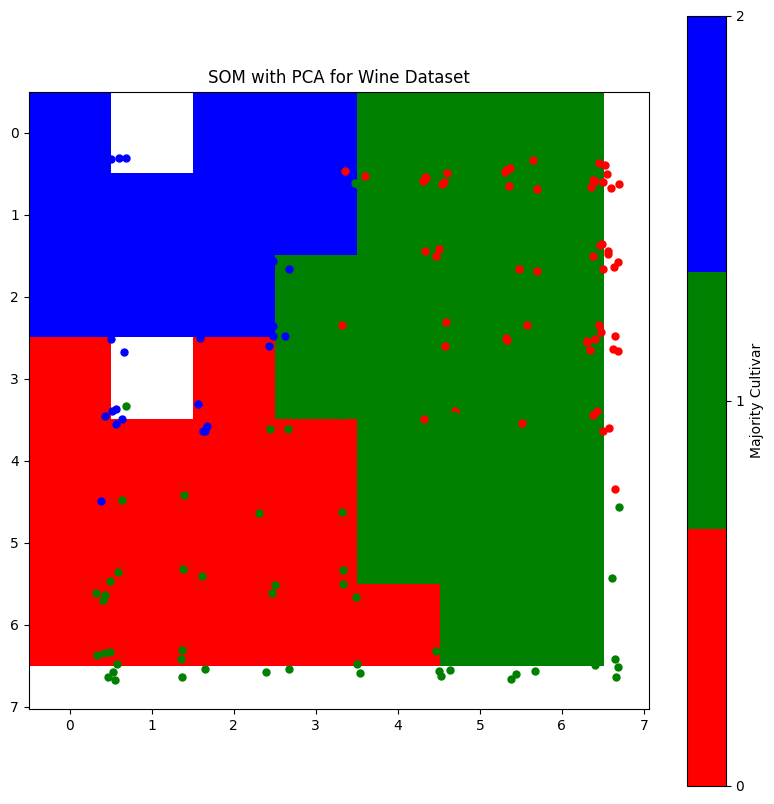

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from minisom import MiniSom
from collections import Counter
from matplotlib.colors import ListedColormap

# Load the Wine dataset
data = load_wine()
X = data.data  # 178 samples, 13 features
y = data.target  # Class labels (0, 1, 2)

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA to reduce to 5 dimensions
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

# Set up the SOM: 7x7 grid, 5 input dimensions (from PCA)
grid_size = 7
som = MiniSom(grid_size, grid_size, 5, sigma=3.0, learning_rate=0.5)

# Train the SOM with 10,000 iterations
som.train_random(X_pca, 10000)

# Map each sample to its BMU
bmu_indices = [som.winner(x) for x in X_pca]

# Collect class labels for each node
node_samples = [[[] for _ in range(grid_size)] for _ in range(grid_size)]
for i, bmu in enumerate(bmu_indices):
    node_samples[bmu[0]][bmu[1]].append(y[i])

# Compute majority class for each node
node_majority = np.full((grid_size, grid_size), -1, dtype=int)
for i in range(grid_size):
    for j in range(grid_size):
        if node_samples[i][j]:
            counter = Counter(node_samples[i][j])
            node_majority[i, j] = counter.most_common(1)[0][0]

# Define colors for the three wine classes
cmap = ListedColormap(['red', 'green', 'blue'])

# Plot the SOM grid
plt.figure(figsize=(10, 10))
node_majority_masked = np.ma.masked_where(node_majority == -1, node_majority)
plt.imshow(node_majority_masked, cmap=cmap, vmin=0, vmax=2)

# Plot each sample as a marker
for i, (x, y_) in enumerate(zip(X_pca, y)):
    bmu = bmu_indices[i]
    # Small random offset to avoid overlap
    offset = (np.random.rand(2) - 0.5) * 0.4
    plt.plot(bmu[0] + 0.5 + offset[0], bmu[1] + 0.5 + offset[1], 'o', color=cmap(y_), markersize=5)

# Add labels and show the plot
plt.colorbar(ticks=[0, 1, 2], label='Majority Cultivar')
plt.title('SOM with PCA for Wine Dataset')
plt.show()

***The U-Matrix visualizes the distances between neighboring nodes in the SOM grid.***

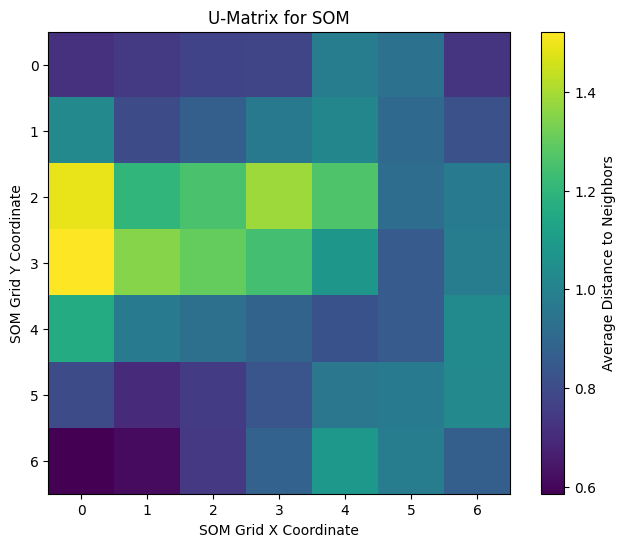

In [6]:
# Calculate U-Matrix
u_matrix = np.zeros((grid_size, grid_size))
for i in range(grid_size):
    for j in range(grid_size):
        # Get the weight vector of the current node
        weight = weights[i, j]
        # Find neighbors (up, down, left, right)
        neighbors = []
        for di, dj in [(-1, 0), (1, 0), (0, -1), (0, 1)]:  # 4-connected neighbors
            ni, nj = i + di, j + dj
            if 0 <= ni < grid_size and 0 <= nj < grid_size:
                neighbors.append(weights[ni, nj])
        # Compute average distance to neighbors
        if neighbors:
            distances = [np.linalg.norm(weight - neighbor) for neighbor in neighbors]
            u_matrix[i, j] = np.mean(distances)

# Plot the U-Matrix
plt.figure(figsize=(8, 6))
plt.imshow(u_matrix, cmap='viridis')
plt.colorbar(label='Average Distance to Neighbors')
plt.title('U-Matrix for SOM')
plt.xlabel('SOM Grid X Coordinate')
plt.ylabel('SOM Grid Y Coordinate')
plt.show()

***The topographic error measures how well the SOM preserves the topology of the input space***
***bold text***

In [5]:
# Calculate Topographic Error
def are_adjacent(pos1, pos2):
    """Check if two positions on the grid are adjacent (including diagonals)."""
    x1, y1 = pos1
    x2, y2 = pos2
    return abs(x1 - x2) <= 1 and abs(y1 - y2) <= 1

# Find the BMU and second-best matching unit for each sample
topographic_errors = 0
weights = som.get_weights()  # Shape: (grid_size, grid_size, 5)
for x in X_pca:
    # Compute distances to all nodes
    distances = np.linalg.norm(weights - x, axis=2)
    # Flatten the distances and get the indices of the smallest two
    flat_indices = np.argsort(distances.flatten())
    bmu_idx = np.unravel_index(flat_indices[0], (grid_size, grid_size))
    second_bmu_idx = np.unravel_index(flat_indices[1], (grid_size, grid_size))
    # Check if BMU and second-best are adjacent
    if not are_adjacent(bmu_idx, second_bmu_idx):
        topographic_errors += 1

# Compute topographic error
topographic_error = topographic_errors / len(X_pca)
print(f"Topographic Error: {topographic_error:.4f}")

Topographic Error: 0.0112


<ipython-input-4-a418c8175f13>:7: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(bmu[0] + 0.5 + offset[0], bmu[1] + 0.5 + offset[1], c=cmap(y_), s=50, alpha=0.8)
/usr/local/lib/python3.11/dist-packages/matplotlib/collections.py:1121: UserWarning: Collection without array used. Make sure to specify the values to be colormapped via the `c` argument.
  warnings.warn("Collection without array used. Make sure to "
<ipython-input-4-a418c8175f13>:13: UserWarning: Mismatched number of handles and labels: len(handles) = 0 len(labels) = 3
  plt.legend(handles=plt.scatter([], [], c='red').legend_elements()[0] +
<ipython-input-4-a418c8175f13>:13: UserWarning: No artists with labels found to put in legend. 

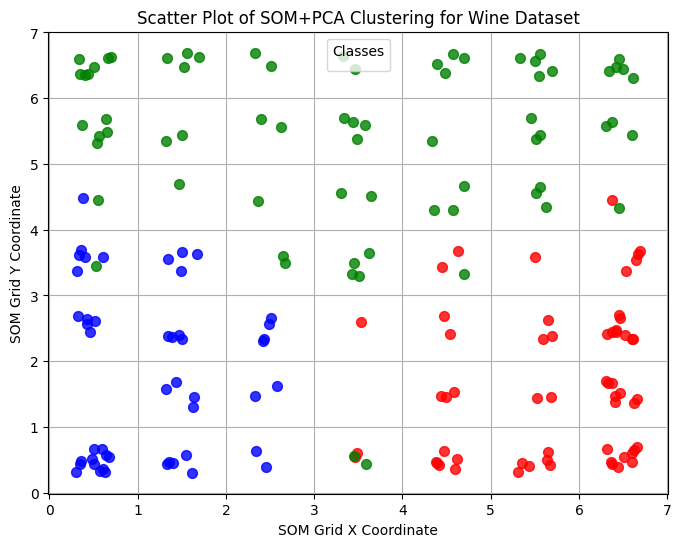

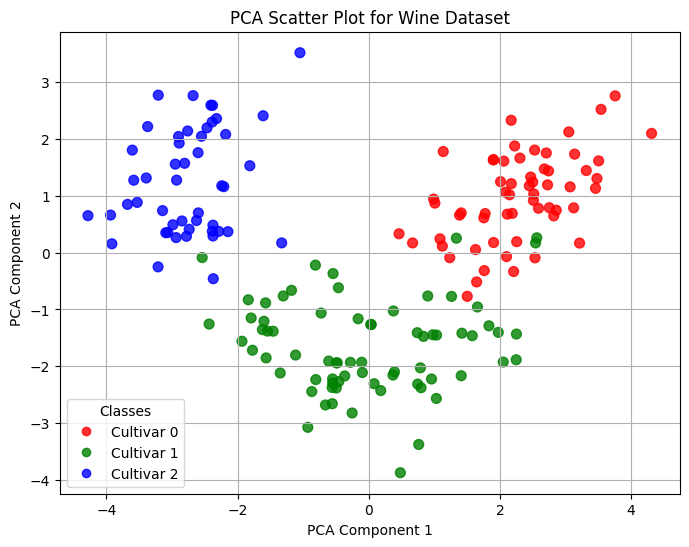

In [4]:
# Plot 2: Scatter plot using SOM BMU coordinates (same clustering as SOM+PCA)
plt.figure(figsize=(8, 6))
for i, (x, y_) in enumerate(zip(X_pca, y)):
    bmu = bmu_indices[i]
    # Use the same offset as the SOM grid plot to match the visualization
    offset = (np.random.rand(2) - 0.5) * 0.4
    plt.scatter(bmu[0] + 0.5 + offset[0], bmu[1] + 0.5 + offset[1], c=cmap(y_), s=50, alpha=0.8)

# Add labels, legend, and grid
plt.xlabel('SOM Grid X Coordinate')
plt.ylabel('SOM Grid Y Coordinate')
plt.title('Scatter Plot of SOM+PCA Clustering for Wine Dataset')
plt.legend(handles=plt.scatter([], [], c='red').legend_elements()[0] +
           plt.scatter([], [], c='green').legend_elements()[0] +
           plt.scatter([], [], c='blue').legend_elements()[0],
           labels=['Cultivar 0', 'Cultivar 1', 'Cultivar 2'], title="Classes")
plt.grid(True)
plt.show()

# Plot 3: Scatter plot using PCA reduced to 2 dimensions (for comparison)
pca_scatter = PCA(n_components=2)
X_pca_scatter = pca_scatter.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca_scatter[:, 0], X_pca_scatter[:, 1], c=y, cmap=cmap, s=50, alpha=0.8)

# Add labels, legend, and grid
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA Scatter Plot for Wine Dataset')
plt.legend(handles=scatter.legend_elements()[0], labels=['Cultivar 0', 'Cultivar 1', 'Cultivar 2'], title="Classes")
plt.grid(True)
plt.show()